In [10]:
import numpy as np
import pandas as pd

df = pd.DataFrame({'price': [20000, 30000, 10000, 40000] 'bins': [0, 30000, 60000, np.int] 'labels': ['low', 'medium', 'high'] })


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [11]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

iris = load_iris()
x = iris.data

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

print("Original shape: ", x.shape)
print("Reduced shape: ", x_pca.shape)

Original shape:  (150, 4)
Reduced shape:  (150, 2)


In [12]:
import numpy as np
from sklearn.decomposition import TruncatedSVD

x = np.random.rand(5, 4)

svd = TruncatedSVD(n_components=2)
x_svd = svd.fit_transform(x)

print("Original: ", x.shape)
print("Reduced: ", x_svd.shape)

Original:  (5, 4)
Reduced:  (5, 2)


In [15]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_iris

iris = load_iris()
x, y = iris.data, iris.target

lda = LinearDiscriminantAnalysis(n_components=2)
x_lda = lda.fit_transform(x, y)

print("Original shape: ", x.shape)
print("Reduced shape: ", x_lda.shape)

Original shape:  (150, 4)
Reduced shape:  (150, 2)


In [16]:
from sklearn.feature_selection import SelectKBest, chi2

x_new = SelectKBest(chi2, k=2).fit_transform(iris.data, iris.target)

print("Original: ", iris.data.shape)
print("Reduced: ", x_new.shape)

Original:  (150, 4)
Reduced:  (150, 2)


In [20]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)

rfe = RFE(model, n_features_to_select=2)
fit = rfe.fit(x, y)

print("Selected features: ", fit.support_)
print("Feature Ranking: ", fit.ranking_)

Selected features:  [False False  True  True]
Feature Ranking:  [3 2 1 1]


In [22]:
from sklearn.linear_model import LassoCV
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)
df_d = diabetes.frame

x = df_d.iloc[:, :-1]
y = df_d.iloc[:, -1]








lasso = LassoCV(cv=5)
lasso.fit(x, y)

print("Coefficients", lasso.coef_)
print("Number of selected features: ", sum(lasso.coef_ != 0))

Coefficients [  -6.49469328 -235.99308032  521.7443693   321.0607768  -569.43813385
  302.45319289   -0.          143.69851474  669.92267515   66.83551067]
Number of selected features:  9


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from math import factorial,sqrt, pi
np.random.seed(42)

Bernoulli sample mean (approx p):  0.2981
Bernoulli sample variance (approx p(1-p)):  0.20923638999999994

Normal sample mean (approx mu):  2.0143617065560466
Normal sample var (approx sigma):  2.249036920136185


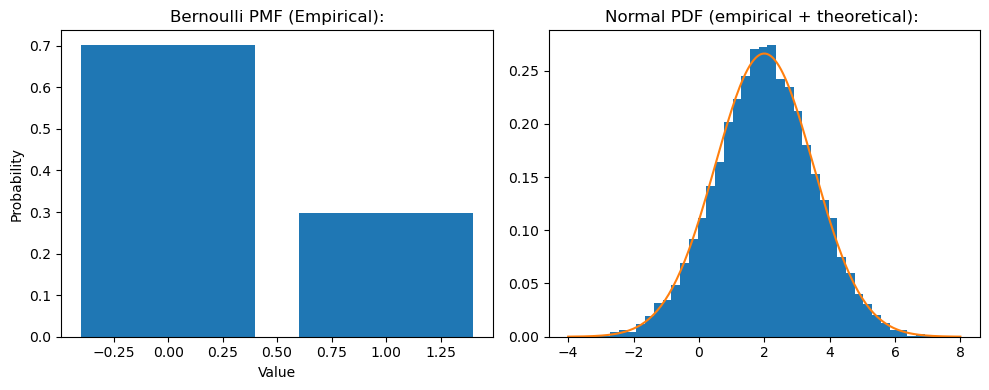

In [15]:
p = 0.3
n_samples = 10000
bern = np.random.binomial(1, p, size=n_samples)
print("Bernoulli sample mean (approx p): ", bern.mean())
print("Bernoulli sample variance (approx p(1-p)): ", bern.var())
mu, sigma = 2.0, 1.5
norm_samples = np.random.normal(mu, sigma, size=n_samples)
print("\nNormal sample mean (approx mu): ", norm_samples.mean())
print("Normal sample var (approx sigma): ", norm_samples.var())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

vals, counts = np.unique(bern, return_counts=True)

axes[0].bar(vals, counts/len(bern))
axes[0].set_title('Bernoulli PMF (Empirical):')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Probability')

axes[1].hist(norm_samples, bins=40, density=True)
x = np.linspace(mu-4*sigma, mu+4*sigma, 200)
axes[1].plot(x, stats.norm.pdf(x, mu, sigma))
axes[1].set_title('Normal PDF (empirical + theoretical): ')
plt.tight_layout()
plt.show()

Binomial theoretical mean, var are 4.0 and 2.4 respectively.
Poisson theoretical mean and var are 3.0 and 3.0 respectively.


LinAlgError: Singular matrix

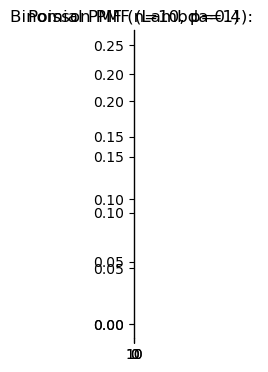

In [22]:
n, p = 10, 0.4
k = np.arange(0, n+1)
pmf_binom = stats.binom.pmf(k, n, p)

print('Binomial theoretical mean, var are', stats.binom.mean(n, p), 'and', stats.binom.var(n, p), 'respectively.')

lan = 3.0
k_p = np.arange(0,15)
pmf_pois = stats.poisson.pmf(k_p, lan)
print('Poisson theoretical mean and var are', stats.poisson.mean(lan), 'and', stats.poisson.var(lan), 'respectively.')

fig, ax = plt.subplots(1, 2, figsize=(0, 4))

ax[0].stem(k, pmf_binom)
ax[0].set_title('Binomial PMF (n=10, p=0.4): ')

ax[1].stem(k_p, pmf_pois)
ax[1].set_title('Poisson PMF (Lambda=1)')
plt.tight_layout()
plt.show()

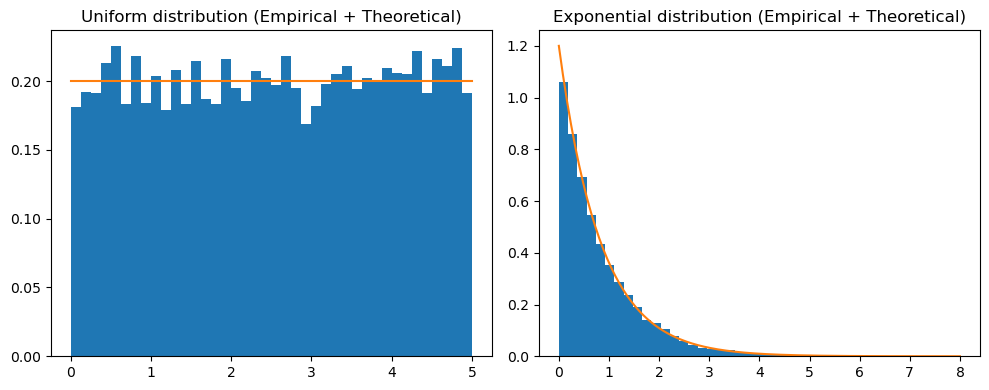

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

a, b = 0, 5
uni_samps = np.random.uniform(a, b, size=10000)
x = np.linspace(a, b, 200)
lam = 1.2
exp_samps = np.random.exponential(1/lam, size=10000)
x_exp = np.linspace(0, 8, 200)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(uni_samps, bins=40, density=True)
ax[0].plot(x, stats.uniform.pdf(x, a, b-a))
ax[0].set_title('Uniform distribution (Empirical + Theoretical)')

ax[1].hist(exp_samps, bins=40, density=True)
ax[1].plot(x_exp, stats.expon.pdf(x_exp, scale=1/lam))
ax[1].set_title('Exponential distribution (Empirical + Theoretical)')

plt.tight_layout()
plt.show()

Empirical covariance:  0.5996838974726316
Empirical correlation:  0.5929071242934725


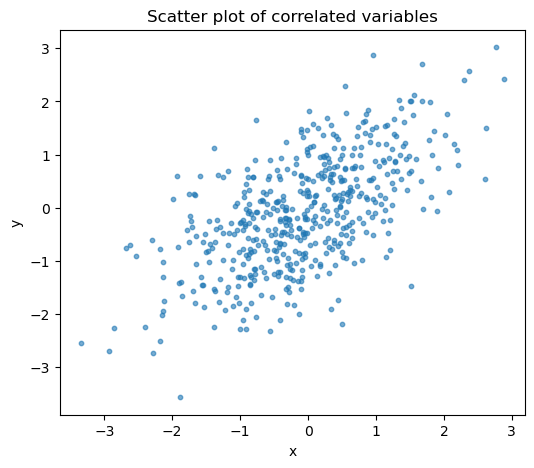

In [21]:
mean = [0, 0]
cov = [[1.0, 0.6], [0.6, 1.0]]
samples = np.random.multivariate_normal(mean, cov, size=5000)
x = samples[:,0]
y = samples[:,1]
print("Empirical covariance: ", np.cov(x, y)[0, 1])
print("Empirical correlation: ", np.corrcoef(x, y)[0, 1])

plt.figure(figsize=(6, 5))
plt.scatter(x[:500], y[:500], s=10, alpha=0.6)
plt.title('Scatter plot of correlated variables')
plt.xlabel('x'); plt.ylabel('y')
plt.show()

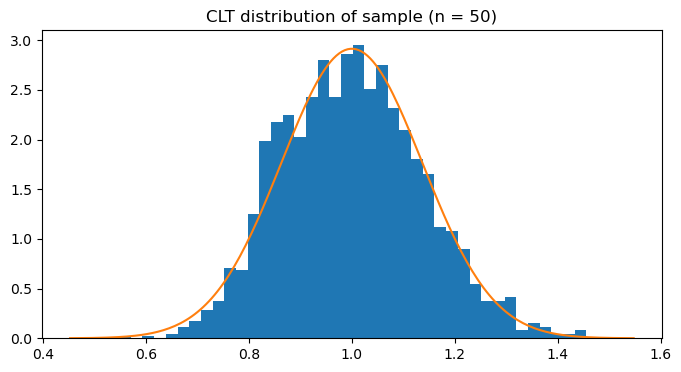

In [28]:
# CLT demonstration

import numpy as np

pop = np.random.exponential(scale=1.0, size=200000)

sample_size = 50
n_trials = 2000

means = [np.mean(np.random.choice(pop, sample_size)) for _ in range(n_trials)]

plt.figure(figsize=(8, 4))
plt.hist(means, bins=40, density=True)
mu_hat = np.mean(means)
sigma_hat = np.std(means)
x = np.linspace(mu_hat-4*sigma_hat, mu_hat+4*sigma_hat, 200)
plt.plot(x, stats.norm.pdf(x, mu_hat, sigma_hat))
plt.title(f"CLT distribution of sample (n = {sample_size})")
plt.show()


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

x = np.array([[1,2], [2,3], [3,3], [6,5],[7,7], [8,6]])
y = np.array([0,0,0,1,1,1])

k = 3 # Number of nearest neighbors

knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(x, y)

sample = np.array([[1, 5]])
predicted_class = knn.predict(sample)
print("Predicted class for [1, 5] is", predicted_class)


Predicted class for [1, 5] is [0]


In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv('btissue.csv')
print(df.head())
print(df.info())

print("\nMissing values per column: ")
print(df.isnull().sum)

print("Summary statistics: ")
print(df.describe())

x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

print("\nFeature shape: ", x.shape)
print("Target shape: ", y.shape)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=123)

print("\nTrain shape: ", x_train.shape)
print("Test shape: ", x_test.shape)

           I0     PA500       HFS          DA          Area       A/DA  \
0  524.794072  0.187448  0.032114  228.800228   6843.598481  29.910803   
1  330.000000  0.226893  0.265290  121.154201   3163.239472  26.109202   
2  551.879287  0.232478  0.063530  264.804935  11888.391830  44.894903   
3  380.000000  0.240855  0.286234  137.640111   5402.171180  39.248524   
4  362.831266  0.200713  0.244346  124.912559   3290.462446  26.342127   

      Max IP          DR           P class  
0  60.204880  220.737212  556.828334   car  
1  69.717361   99.084964  400.225776   car  
2  77.793297  253.785300  656.769449   car  
3  88.758446  105.198568  493.701814   car  
4  69.389389  103.866552  424.796503   car  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   I0      106 non-null    float64
 1   PA500   106 non-null    float64
 2   HFS     106 non-null    flo


.... KNN Results ...
Accuracy score:  0.46875
Precision score:  0.34289321789321786
Recall:  0.4174603174603175
F1 score:  0.3702686202686203


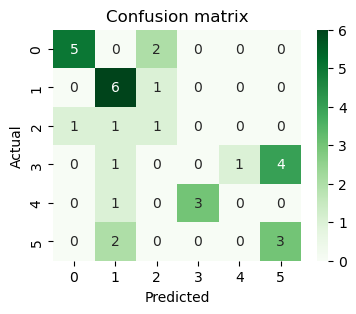

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=3)
model = knn.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("\n.... KNN Results ...")
print("Accuracy score: ", accuracy_score(y_test, y_pred))
print("Precision score: ", precision_score(y_test, y_pred, average='macro', zero_division=0))
print("Recall: ", recall_score(y_test, y_pred, average='macro', zero_division=0))
print("F1 score: ", f1_score(y_test, y_pred, average='macro', zero_division=0))
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d',cmap='Greens')
plt.title('Confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



*** Decision Tree Results ***
Accuracy score:  0.46875
Feature importance:  [0.25401208 0.         0.03657752 0.09449581 0.         0.21595432
 0.08474244 0.         0.31421784]
Precision score:  0.34289321789321786
Recall:  0.4174603174603175
F1 score:  0.3702686202686203


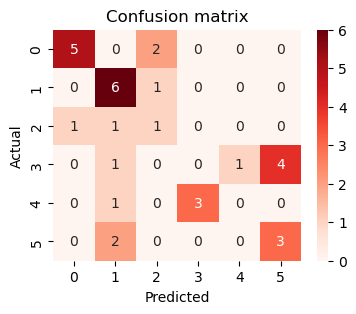

In [26]:
from sklearn.tree import DecisionTreeClassifier

df = DecisionTreeClassifier(max_depth=5, random_state=123)

model = df.fit(x_train, y_train)
y_pred_dt = model.predict(x_test) 

print("\n*** Decision Tree Results ***")
print("Accuracy score: ", accuracy_score(y_test, y_pred))
print("Feature importance: ", df.feature_importances_)
print("Precision score: ", precision_score(y_test, y_pred, average='macro', zero_division=0))
print("Recall: ", recall_score(y_test, y_pred, average='macro', zero_division=0))
print("F1 score: ", f1_score(y_test, y_pred, average='macro', zero_division=0))
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d',cmap='Reds')
plt.title('Confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


...          Results          ...

Accuracy:  0.65625
Precision:  0.7102272727272728
Recall:  0.6456349206349207
F1 score:  0.6115893365893366


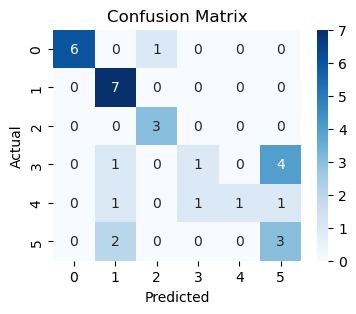

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv('btissue.csv')
x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=123)
rf = RandomForestClassifier()
model = rf.fit(x_train, y_train)

y_pred_rf = model.predict(x_test)

print("\n...          Results          ...\n")
print("Accuracy: ", accuracy_score(y_test, y_pred_rf))
print("Precision: ", precision_score(y_test, y_pred_rf, average='macro', zero_division=0))
print("Recall: ", recall_score(y_test, y_pred_rf, average='macro', zero_division=0))
print("F1 score: ", f1_score(y_test, y_pred_rf, average='macro', zero_division=0))

cf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(4, 3))
sns.heatmap(cf, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.Linear_Model import LinearRegression

x = np.array([13, 25, 18, 23, 24, 22, 22, 19, 19, 18, 24, 11, 24, 18,23]).reshape(-1, 1)
y = np.array([40, 53, 58, 60, 50, 61, 60, 61, 60, 32, 62, 30, 39, 49,60])

lr = LinearRegression().fit(x, y)
plt.scatter(x, y)
plt.plot(x, lr.predict(x))
plt.xlabel("Internal Marks")
plt.ylabel("External Marks")
plt.title("Linear Regression")
plt.show()

print("Intercept: ", lr.intercept_)
print("Slope: ", lr_coef_[0])
print("R2 Score: ", lr.score(x, y))

ModuleNotFoundError: No module named 'sklearn'

In [4]:
pip install sklearn

Defaulting to user installation because normal site-packages is not writeable
  Preparing metadata (setup.py) ... error
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to 

In [5]:
pip install scikit.sklearn

Defaulting to user installation because normal site-packages is not writeable
ERROR: Could not find a version that satisfies the requirement scikit.sklearn (from versions: none)
ERROR: No matching distribution found for scikit.sklearn
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/9.7 MB 276.7 kB/s eta 0:00:27:27
ERROR: Exception:
Traceback (most recent call last):
  File "/usr/lib/python3/dist-packages/pip/_vendor/urllib3/response.py", line 438, in _error_catcher
    yield
  File "/usr/lib/python3/dist-packages/pip/_vendor/urllib3/response.py", line 519, in read
    data = self._fp.read(amt) if not fp_closed else b""
  File "/usr/lib/python3/dist-packages/pip/_vendor/cachecontrol/filewrapper.py", line 90, in read
    data = self.__fp.read(amt)
  File "/usr/lib/python3.10/http/client.py", line 466, in read
    s = self.fp.read(amt)
  File "/usr/lib/python3.10/socket.py", line 705, in readinto
    return self._sock.recv_into(b)
  File "/usr/lib/python3.10/ssl.py", line 1303, in recv_into
    return self.read(nbytes, buffer)
  File "/usr/lib/python3.10/ssl.py", line 1159, in read
    return self._sslobj.read(len, buffer)
TimeoutError: The

In [1]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/9.7 MB 217.3 kB/s eta 0:00:36
ERROR: Exception:
Traceback (most recent call last):
  File "/usr/lib/python3/dist-packages/pip/_vendor/urllib3/response.py", line 438, in _error_catcher
    yield
  File "/usr/lib/python3/dist-packages/pip/_vendor/urllib3/response.py", line 519, in read
    data = self._fp.read(amt) if not fp_closed else b""
  File "/usr/lib/python3/dist-packages/pip/_vendor/cachecontrol/filewrapper.py", line 90, in read
    data = self.__fp.read(amt)
  File "/usr/lib/python3.10/http/client.py", line 466, in read
    s = self.fp.read(amt)
  File "/usr/lib/python3.10/socket.py", line 705, in readinto
    return self._sock.recv_into(b)
  File "/usr/lib/python3.10/ssl.py", line 1303, in recv_into
    return self.read(nbytes, buffer)
  File "/usr/lib/python3.10/ssl.py", line 1159, in read
    return self._sslobj.read(len, buffer)
TimeoutError: The re

In [2]:
pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 24.2 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 KB 26.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 47.0 MB/s eta 0:00:00m eta 0:00:010:01:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.Linear_Model import LinearRegression

x = np.array([13, 25, 18, 23, 24, 22, 22, 19, 19, 18, 24, 11, 24, 18,23]).reshape(-1, 1)
y = np.array([40, 53, 58, 60, 50, 61, 60, 61, 60, 32, 62, 30, 39, 49,60])

lr = LinearRegression().fit(x, y)
plt.scatter(x, y)
plt.plot(x, lr.predict(x))
plt.xlabel("Internal Marks")
plt.ylabel("External Marks")
plt.title("Linear Regression")
plt.show()

print("Intercept: ", lr.intercept_)
print("Slope: ", lr_coef_[0])
print("R2 Score: ", lr.score(x, y))


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/usr/lib/python3/dist-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/usr/lib/python3/dist-packages/traitlets/config/application.py", line 846, in launch_instance
    app.start()
  File "/usr/lib/python3/dist-packages/ipykernel/kernelapp.py", line 677, in start
    s

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

In [2]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.Linear_Model import LinearRegression

x = np.array([13, 25, 18, 23, 24, 22, 22, 19, 19, 18, 24, 11, 24, 18,23]).reshape(-1, 1)
y = np.array([40, 53, 58, 60, 50, 61, 60, 61, 60, 32, 62, 30, 39, 49,60])

lr = LinearRegression().fit(x, y)
plt.scatter(x, y)
plt.plot(x, lr.predict(x))
plt.xlabel("Internal Marks")
plt.ylabel("External Marks")
plt.title("Linear Regression")
plt.show()

print("Intercept: ", lr.intercept_)
print("Slope: ", lr_coef_[0])
print("R2 Score: ", lr.score(x, y))


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/usr/lib/python3/dist-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/usr/lib/python3/dist-packages/traitlets/config/application.py", line 846, in launch_instance
    app.start()
  File "/usr/lib/python3/dist-packages/ipykernel/kernelapp.py", line 677, in start
    s

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

In [4]:
pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

x = np.array([13, 25, 18, 23, 24, 22, 22, 19, 19, 18, 24, 11, 24, 18,23]).reshape(-1, 1)
y = np.array([40, 53, 58, 60, 50, 61, 60, 61, 60, 32, 62, 30, 39, 49,60])

lr = LinearRegression().fit(x, y)
plt.scatter(x, y)
plt.plot(x, lr.predict(x))
plt.xlabel("Internal Marks")
plt.ylabel("External Marks")
plt.title("Linear Regression")
plt.show()

print("Intercept: ", lr.intercept_)
print("Slope: ", lr_coef_[0])
print("R2 Score: ", lr.score(x, y))


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/usr/lib/python3/dist-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/usr/lib/python3/dist-packages/traitlets/config/application.py", line 846, in launch_instance
    app.start()
  File "/usr/lib/python3/dist-packages/ipykernel/kernelapp.py", line 677, in start
    s

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

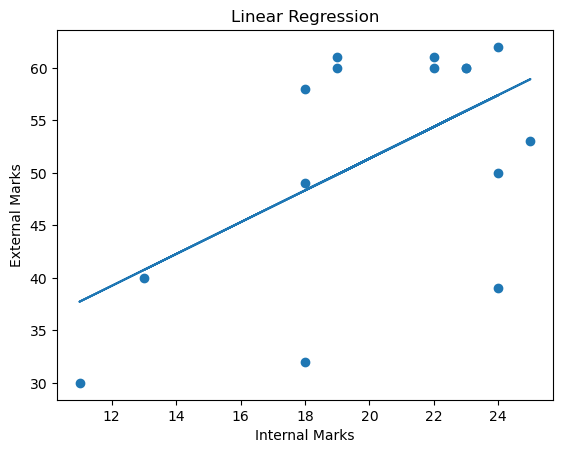

Intercept:  21.083333333333336
Slope:  1.514026402640264
R2 Score:  0.31511211140017603


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

x = np.array([13, 25, 18, 23, 24, 22, 22, 19, 19, 18, 24, 11, 24, 18,23]).reshape(-1, 1)
y = np.array([40, 53, 58, 60, 50, 61, 60, 61, 60, 32, 62, 30, 39, 49,60])

lr = LinearRegression().fit(x, y)
plt.scatter(x, y)
plt.plot(x, lr.predict(x))
plt.xlabel("Internal Marks")
plt.ylabel("External Marks")
plt.title("Linear Regression")
plt.show()

print("Intercept: ", lr.intercept_)
print("Slope: ", lr.coef_[0])
print("R2 Score: ", lr.score(x, y))